# 4.10. Interpretación de los gráficos de colores de esfuerzos y deformaciones de una viga simplemente apoyada

Por:
- Michael Heredia Pérez
- [mherediap@unal.edu.co](mherediap@unal.edu.co)
- 2026-02-22


## El problema

En este cuaderno, vamos a realizar el análisis de los gráficos de esfuerzos y deformaciones para una viga simplemente apoyada con una carga uniformemente distriuida, como se muestra en la figura. 

<img src="figs/viga-simplemente-apoyada.png" width="600">

## Librerías y funciones a utilizar

Primero, definimos algunos parámetros en la librería matplotlib para darle estilo al texto de las gráficas. 

In [1]:
import matplotlib as mpl

# Configure matplotlib for STIX font - comprehensive setup
mpl.rcParams.update({
    # Primary font configuration
    "font.family": "serif",              # Use serif family
    "font.serif": ["STIX", "STIXGeneral", "STIX Two Text"], # STIX font priority
    "mathtext.fontset": "stix",          # Math expressions in STIX
    
    # Explicit font specification for all text elements
    "axes.labelsize": 18,
    "axes.titlesize": 18, 
    "legend.fontsize": 16,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "font.size": 16,
    
    # Line properties
    "lines.linewidth": 1.5
})

In [2]:
# Importamos las librerías necesarias

import numpy as np
import matplotlib.pyplot as plt

Vamos a realizar muchas figuras, una por cada esfuerzo estudiado. Así que creamos una función para impirmir estas figuras y de ser necesario, guardarlas. 

In [3]:
# Función para guardar las imágenes generadas.
from funciones_plot import save_image

# Función para graficar los esfuerzos y deformaciones.
from funciones_plot import plot_esf_def

# Función para graficar el campo escalar del esfuerzo.
from funciones_plot import plot_3d_esf_def

# Función de graficación interactiva del campo escalar del esfuerzo.
from funciones_plot import plot_3d_esf_def_interactive

# Función para graficar fuerza cortante y momento flector.
from funciones_plot import plot_v_m

## Formulación y análisis.

Definimos las constantes de nuestro problema.

In [4]:
# Propiedades geométricas de la viga.
c = 0.50    # m, altura = 2c.
L = 3.00    # m, luz    = 2L.
t = 1.00    # m, espesor unitario.

# Se calcula el momento de inercia centroidal I = bh^3/12, con b=1 y h=2c.
I = (t * (2*c)**3) / 12 # m^4.

# Carga aplicada
q = -10.0   # kN/m.

# Propiedades del material
E  = 21e6         # kPa = 21 GPa, módulo de Young.
nu = 0.23         # ad          , coeficiente de Poisson.
G = E/(2*(1+nu))  # kPa         , módulo de cortante.

Las funciones que determinan el estado de esfuerzos de la viga, fueron calculadas al solucionar la función de tensión de Airy. Estas ecuaciones las resolveremos en una discretización de la viga. 

In [5]:
# Se crea la grilla de puntos donde se harán los cálculos.
nnds_x = 50
nnds_y = 20
x, y = np.meshgrid( np.linspace(-L, L, nnds_x), np.linspace(-c, c, nnds_y) )

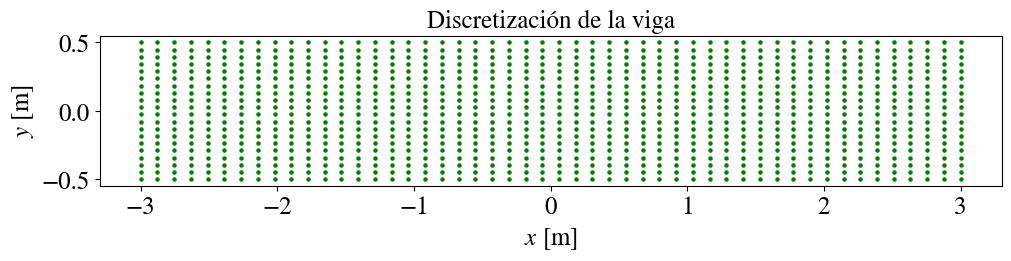

Figure saved to: results_plots/discretizacion_viga.pdf
Figure saved to: results_plots/discretizacion_viga.eps
Figure saved to: results_plots/discretizacion_viga.png


In [6]:
fig, ax = plt.subplots(figsize=(10, 3), constrained_layout=True)
ax.scatter(x, y, s=5, color="green")    # solo ploteamos puntos.
ax.set_xlabel("$x$ [m]")
ax.set_ylabel("$y$ [m]", rotation=90)
ax.set_aspect("equal", adjustable="box")
ax.set_title("Discretización de la viga")
plt.show()
save_image(fig, "discretizacion_viga")

Los esfuerzos al interior de la viga estarán caracterizados por las siguientes ecuaciones:

$$\begin{align*}
\sigma_x(x, y, z) &= -\frac{q}{2I}\left(x^2y - \frac{2}{3}y^3 + \frac{2}{5}c^2y - L^2y\right)\\
\sigma_y(x, y, z) &= -\frac{q}{2I}\left(\frac{1}{3}y^3 - c^2y - \frac{2}{3}c^3\right)\\
\sigma_z(x, y, z) &= 0\\
\tau_{xy}(x, y, z) &= -\frac{q}{2I}(c^2 - y^2)x\\
\tau_{xz}(x, y, z) &= 0\\
\tau_{yz}(x, y, z) &= 0
\end{align*}$$

Estas ecuaciones fueron obtenidas mediante la **función de tensión de Airy**. Vemos que la viga puede considerarse como un caso de tensión plana ($\sigma_z = \tau_{xz} = \tau_{yz} = 0$).

Dichas funciones de esfuerzos las calcularemos en cada punto discretizado de la viga. A partir de la Ley de Hooke podremos calcular las deformaciones en la viga, y consecuentemente los esfuerzos y direcciones principales.

**Nota:** Estas funciones fueron obtenidas en el siguiente código:
[https://github.com/diegoandresalvarez/solidos/blob/master/codigo/05_ec_diferenciales_solidos/5.07_viga_simplemente_apoyada_Airy.ipynb](https://github.com/diegoandresalvarez/solidos/blob/master/codigo/05_ec_diferenciales_solidos/5.07_viga_simplemente_apoyada_Airy.ipynb)

In [7]:
# Se definen los esfuerzos (en tensión plana sz = txz = tyz = 0), eq (4.45)
sx  = -(q/(2*I))*(x**2*y - 2*y**3/3 + 2*c**2*y/5 - L**2*y)
sy  = -(q/(2*I))*(y**3/3 - c**2*y - 2*c**3/3)
txy = -(q/(2*I))*(c**2 - y**2)*x

# Se calculan las deformaciones.
ex  = (1/E)*(sx - nu*sy)
ey  = (1/E)*(sy - nu*sx)
ez  = -(nu/E)*(sx + sy)
gxy = txy/G

# Se calculan los esfuerzos principales, los esfuerzos cortantes máximos y sus 
# ángulos.
tmax = np.sqrt( ((sx - sy)/2)**2 + txy**2 )
s1 = (sx + sy)/2 + tmax
s2 = (sx + sy)/2 - tmax
t1 = np.arctan2(2*txy, sx-sy)/2     
t2 = t1 + np.pi/2                   # t1 + 90°

## Gráficos de esfuerzos $\sigma_x$, $\sigma_y$, $\tau_{xy}$

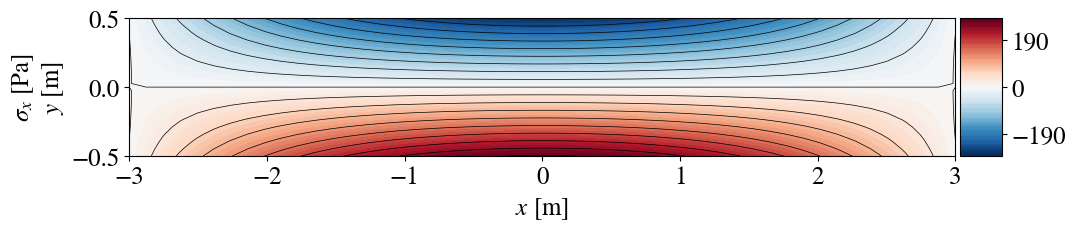

Figure saved to: results_plots/sigma_x.pdf
Figure saved to: results_plots/sigma_x.eps
Figure saved to: results_plots/sigma_x.png


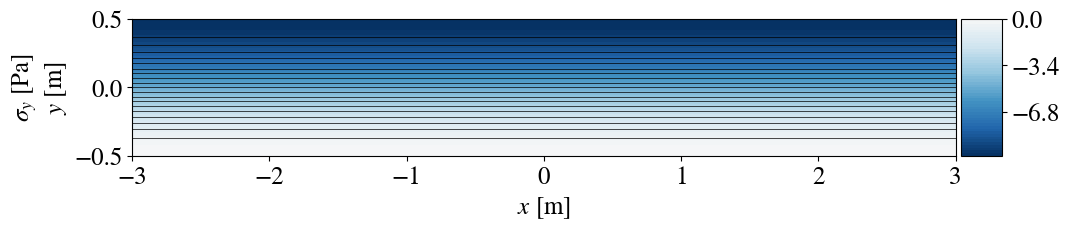

Figure saved to: results_plots/sigma_y.pdf
Figure saved to: results_plots/sigma_y.eps
Figure saved to: results_plots/sigma_y.png


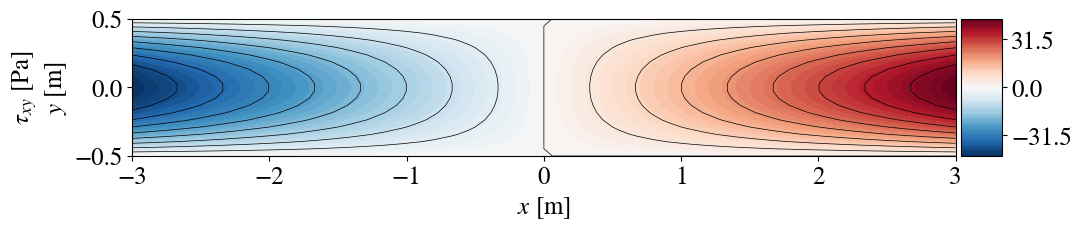

Figure saved to: results_plots/tau_xy.pdf
Figure saved to: results_plots/tau_xy.eps
Figure saved to: results_plots/tau_xy.png


In [8]:
plot_esf_def(x, y, sx,  r"$\sigma_x$ [Pa]", "sigma_x")
plot_esf_def(x, y, sy,  r"$\sigma_y$ [Pa]", "sigma_y")
plot_esf_def(x, y, txy, r"$\tau_{xy}$ [Pa]", "tau_xy")

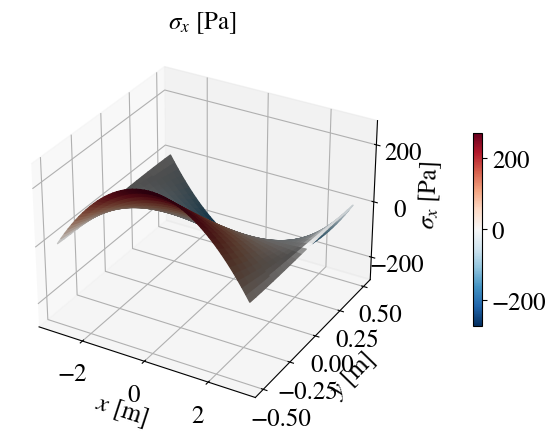

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Figure saved to: results_plots/sigma_x_3d.pdf
Figure saved to: results_plots/sigma_x_3d.eps
Figure saved to: results_plots/sigma_x_3d.png


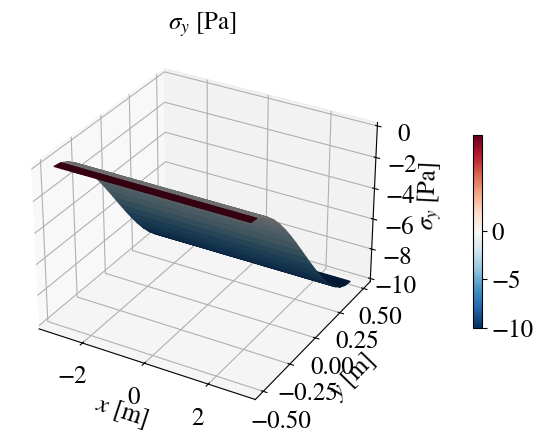

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Figure saved to: results_plots/sigma_y_3d.pdf
Figure saved to: results_plots/sigma_y_3d.eps
Figure saved to: results_plots/sigma_y_3d.png


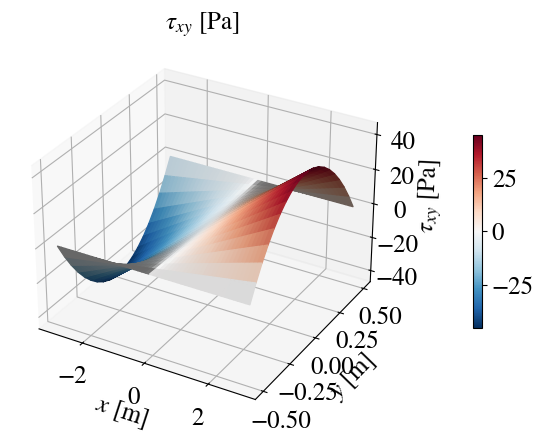

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Figure saved to: results_plots/tau_xy_3d.pdf
Figure saved to: results_plots/tau_xy_3d.eps
Figure saved to: results_plots/tau_xy_3d.png


In [9]:
# Veamos ahora el campo escalar que tenemos asociado a cada esfuerzo.
plot_3d_esf_def(x, y, sx,  r"$\sigma_x$ [Pa]",    "sigma_x_3d")
plot_3d_esf_def(x, y, sy, r"$\sigma_y$ [Pa]",    "sigma_y_3d")
plot_3d_esf_def(x, y, txy, r"$\tau_{xy}$ [Pa]",   "tau_xy_3d")

In [10]:
plot_3d_esf_def_interactive(x, y, sx,  r"$\sigma_x$ [Pa]")
plot_3d_esf_def_interactive(x, y, sy,  r"$\sigma_y$ [Pa]")
plot_3d_esf_def_interactive(x, y, txy, r"$\tau_{xy}$ [Pa]")

/home/michahp/anaconda3/lib/python3.12/site-packages/kaleido/_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




## Gráficos de deformaciones $\varepsilon_x$, $\varepsilon_y$, $\varepsilon_z$, $\gamma_{xy}$

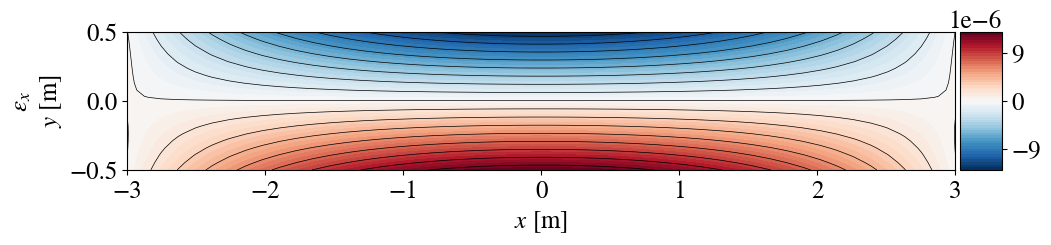

Figure saved to: results_plots/epsilon_x.pdf
Figure saved to: results_plots/epsilon_x.eps
Figure saved to: results_plots/epsilon_x.png


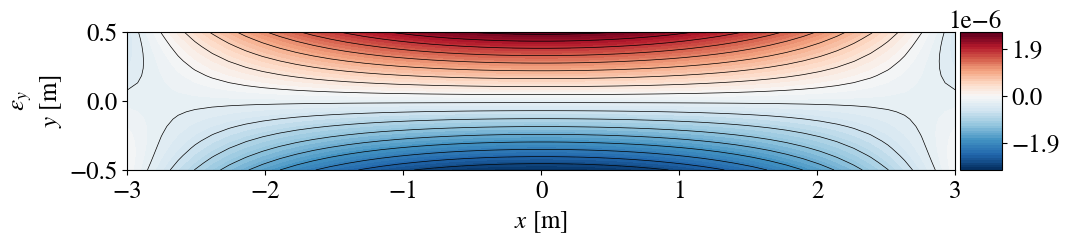

Figure saved to: results_plots/epsilon_y.pdf
Figure saved to: results_plots/epsilon_y.eps
Figure saved to: results_plots/epsilon_y.png


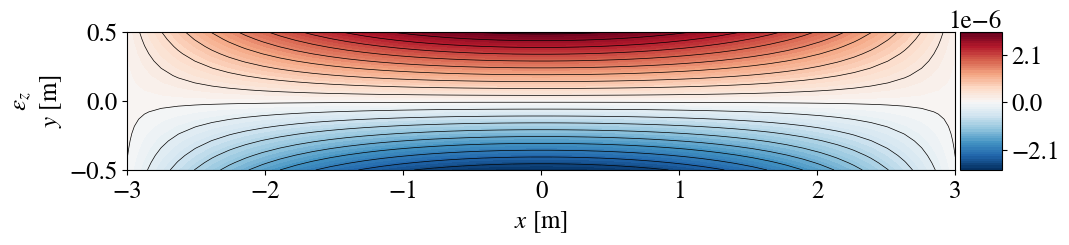

Figure saved to: results_plots/epsilon_z.pdf
Figure saved to: results_plots/epsilon_z.eps
Figure saved to: results_plots/epsilon_z.png


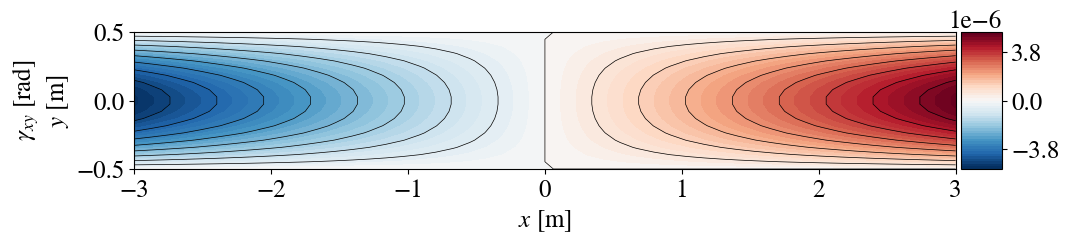

Figure saved to: results_plots/gamma_xy.pdf
Figure saved to: results_plots/gamma_xy.eps
Figure saved to: results_plots/gamma_xy.png


In [11]:
plot_esf_def(x, y, ex,  r"$\epsilon_x$", "epsilon_x")
plot_esf_def(x, y, ey,  r"$\epsilon_y$", "epsilon_y")
plot_esf_def(x, y, ez,  r"$\epsilon_z$", "epsilon_z")
plot_esf_def(x, y, gxy, r"$\gamma_{xy}$ [rad]", "gamma_xy")

## Gráficos de los esfuerzos principales con sus direcciones

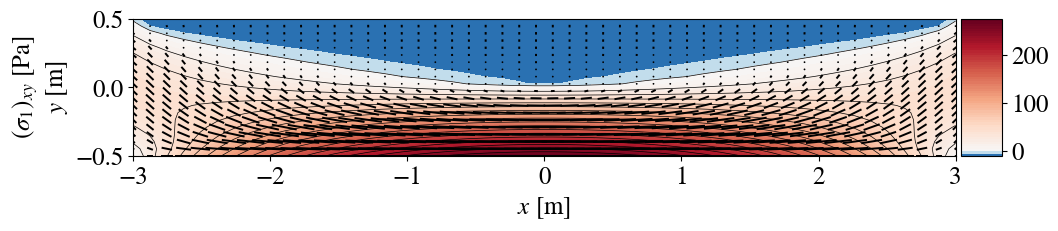

Figure saved to: results_plots/s1.pdf
Figure saved to: results_plots/s1.eps
Figure saved to: results_plots/s1.png


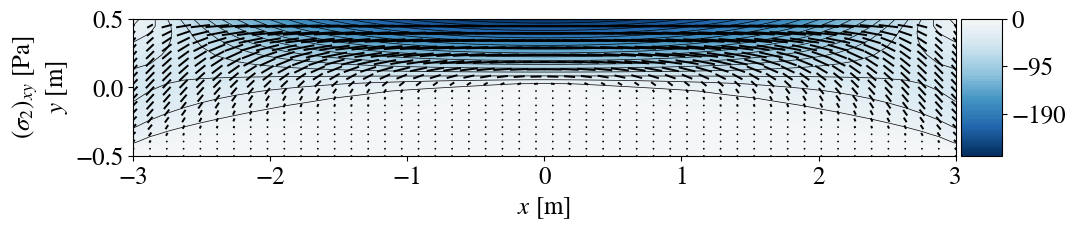

Figure saved to: results_plots/s2.pdf
Figure saved to: results_plots/s2.eps
Figure saved to: results_plots/s2.png


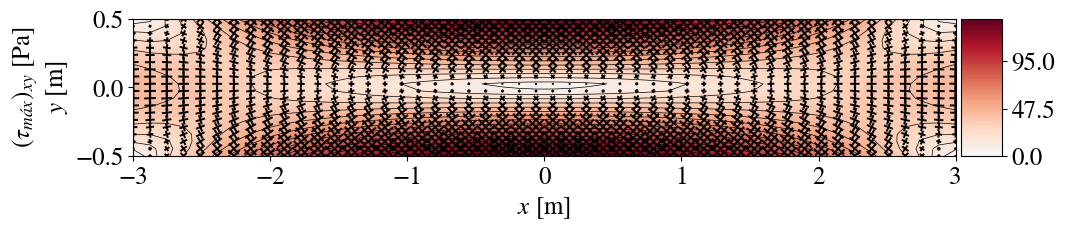

Figure saved to: results_plots/tmax.pdf
Figure saved to: results_plots/tmax.eps
Figure saved to: results_plots/tmax.png


In [12]:
plot_esf_def(x, y, s1,   r"$(\sigma_1)_{xy}$ [Pa]", "s1", t1)
plot_esf_def(x, y, s2,   r"$(\sigma_2)_{xy}$ [Pa]", "s2", t2)
plot_esf_def(x, y, tmax, r"$(\tau_{máx})_{xy}$ [Pa]", "tmax", [t1-np.pi/4, t1+np.pi/4])

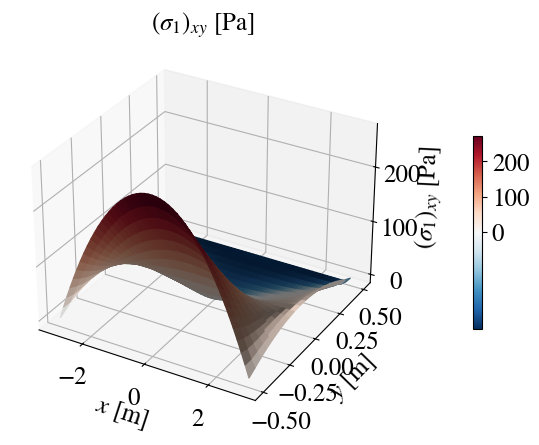

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Figure saved to: results_plots/s1_3d.pdf
Figure saved to: results_plots/s1_3d.eps
Figure saved to: results_plots/s1_3d.png


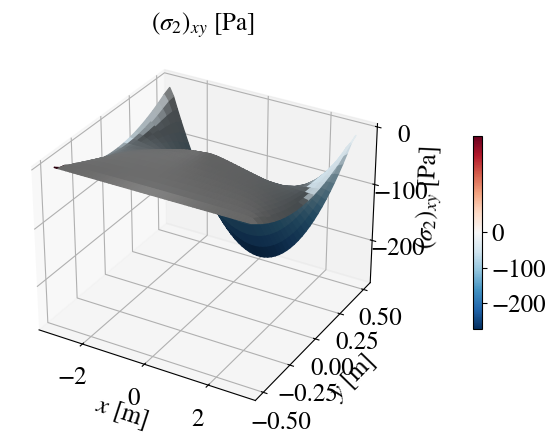

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Figure saved to: results_plots/s2_3d.pdf
Figure saved to: results_plots/s2_3d.eps
Figure saved to: results_plots/s2_3d.png


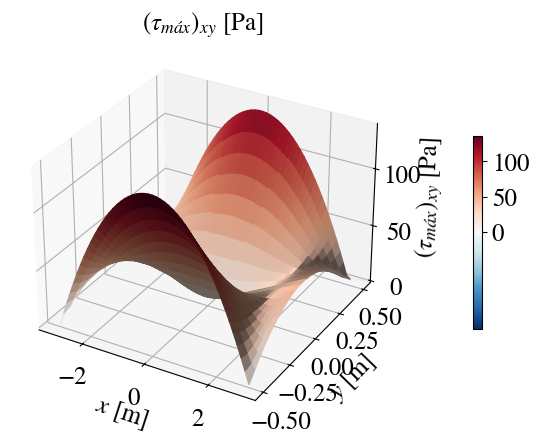

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Figure saved to: results_plots/tmax_3d.pdf
Figure saved to: results_plots/tmax_3d.eps
Figure saved to: results_plots/tmax_3d.png


In [13]:
# Veamos la superficie del campo escalar de cada esfuerzo principal.
plot_3d_esf_def(x, y, s1,   r"$(\sigma_1)_{xy}$ [Pa]",       "s1_3d")
plot_3d_esf_def(x, y, s2,   r"$(\sigma_2)_{xy}$ [Pa]",       "s2_3d")
plot_3d_esf_def(x, y, tmax, r"$(\tau_{máx})_{xy}$ [Pa]",     "tmax_3d")

In [14]:
plot_3d_esf_def_interactive(x, y, s1,   r"$(\sigma_1)_{xy}$ [Pa]")
plot_3d_esf_def_interactive(x, y, s2,   r"$(\sigma_2)_{xy}$ [Pa]")
plot_3d_esf_def_interactive(x, y, tmax, r"$(\tau_{máx})_{xy}$ [Pa]")

### ¿Por qué vemos colores negativos en $(\sigma_1)_{xy}$ ?

Por definición, los esfuerzos principales se ordenan como:

$$(\sigma_1)_{xy} \geq (\sigma_2)_{xy}$$

Es decir, $(\sigma_1)_{xy}$ es simplemente el **mayor** de los dos esfuerzos principales, pero esto
**no implica que $(\sigma_1)_{xy}$ sea positivo**. En zonas donde el estado de esfuerzos es
bicompresivo (compresión en todas las direcciones), ambos esfuerzos principales
son negativos, y $(\sigma_1)_{xy}$ corresponde al "menos negativo" de los dos.

En una viga simplemente apoyada con carga distribuida, esto ocurre en las zonas
cercanas a los apoyos, donde coexisten:

- $\sigma_y$ fuertemente negativo: compresión vertical producida por la carga aplicada.
- $\sigma_x$ moderadamente negativo: compresión horizontal en esa zona de la viga.

La combinación de ambos produce un **estado bicompresivo**, donde el círculo de
Mohr se ubica completamente en la zona negativa del eje $\sigma$, resultando en
$(\sigma_1)_{xy} < 0$ y $(\sigma_2)_{xy} < 0$.

Por lo tanto, los valores negativos observados en el gráfico de $(\sigma_1)_{xy}$ son
**físicamente correctos** y no corresponden a ningún error numérico.

In [15]:
idx = np.unravel_index(np.argmin(s1), s1.shape)

print(f"Valor mínimo de σ₁: {s1[idx]:.4f} Pa")
print(f"Valor de σ₂ en esa misma posición: {s2[idx]:.4f} Pa")
print(f"¿Se cumple σ₁ ≥ σ₂? {s1[idx] >= s2[idx]}")
print(f"Posición: x = {x[idx[0], idx[1]]:.4f} m, y = {y[idx[0], idx[1]]:.4f} m")

Valor mínimo de σ₁: -10.0000 Pa
Valor de σ₂ en esa misma posición: -246.6980 Pa
¿Se cumple σ₁ ≥ σ₂? True
Posición: x = -0.9184 m, y = 0.5000 m


## Diagramas de fuerza cortante y momento flector

Adicionalmente, podemos obtener los diagramas de fuerza cortante y momento flector asociados, a partir de las siguientes ecuaciones:

$$V(x) = -\iint \tau_{xy}(x, y, z) \, dy \, dz = qx$$

$$M(x) = -\iint y \sigma_x(x, y, z) \, dy \, dz = -\frac{q}{2}\left(L^2 - x^2\right)$$

Estas ecuaciones fueron calculadas en el siguiente código: [4_10_4_relacion_esf_V_M_viga_simp_apoyada.ipynb](https://github.com/michaelherediaperez/medio-continuo/blob/main/codigos/cap_04/4_10_4_relacion_esf_V_M_viga_simp_apoyada.ipynb)

In [16]:
# Dominio 1D a lo largo de la luz: x ∈ [-L, L]
nx = 400
x1d = np.linspace(-L, L, nx)

# Funciones internas
V = q * x1d
M = -(q/2.0) * (L**2 - x1d**2)

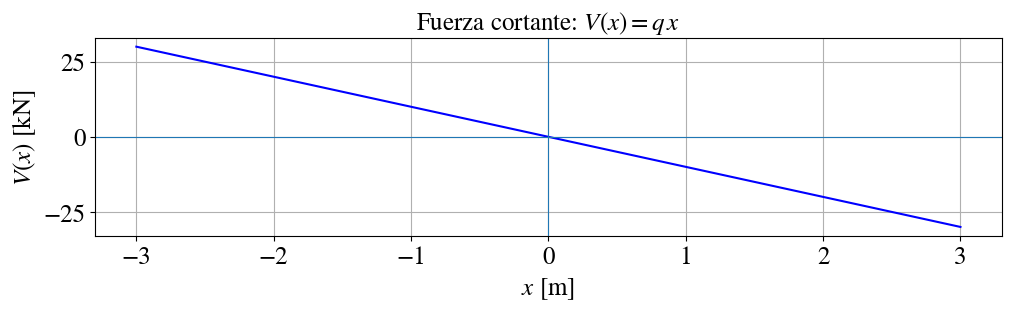

Figure saved to: results_plots/fuerza_cortante.pdf
Figure saved to: results_plots/fuerza_cortante.eps
Figure saved to: results_plots/fuerza_cortante.png


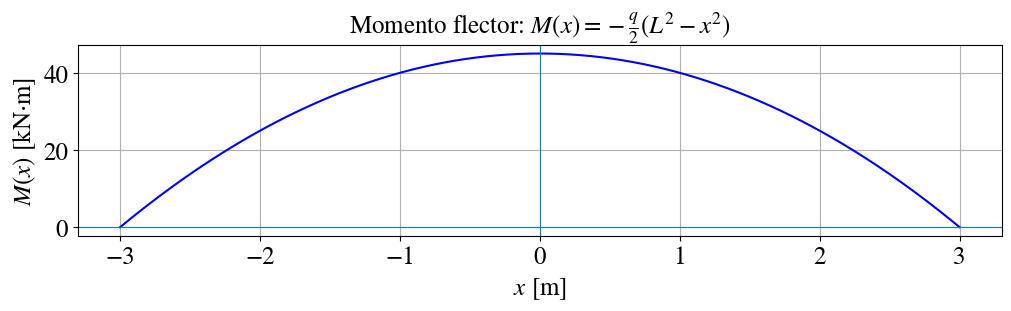

Figure saved to: results_plots/momento_flector.pdf
Figure saved to: results_plots/momento_flector.eps
Figure saved to: results_plots/momento_flector.png


In [17]:
plot_v_m(x1d, V, r"Fuerza cortante: $V(x)=q\,x$", "fuerza_cortante")
plot_v_m(x1d, M, r"Momento flector: $M(x)=-\frac{q}{2}\left(L^2-x^2\right)$", "momento_flector")

## Trayectorias de los esfuerzos

Las trayectorias de los esfuerzos principales $(\sigma_1)_{xy}$ y $(\sigma_2)_{xy}$, también llamadas *líneas isostáticas*, son la solución del siguiente par de ecuacioens diferenciales:

$$
\frac{dy}{dx}
=
-\frac{\sigma_x-\sigma_y}{2\tau_{xy}}
\;\pm\;
\sqrt{
\left(\frac{\sigma_x-\sigma_y}{2\tau_{xy}}\right)^2
+1
};
\qquad
$$

cuya característica es que son mutuamente ortogonales entre si.

In [18]:
# Se definen los esfuerzos (en tensión plana: sz = txz = tyz = 0)
sx  = lambda x, y: -(q/(2*I)) * (x**2*y - 2*y**3/3 + 2*c**2*y/5 - L**2*y)
sy  = lambda x, y: -(q/(2*I)) * (y**3/3 - c**2*y - 2*c**3/3)
txy = lambda x, y: -(q/(2*I)) * (c**2 - y**2) * x

In [19]:
# Término común a ambas ecuaciones diferenciales de las líneas isostáticas
R   = lambda x, y: -(sx(x,y) - sy(x,y)) / (2*txy(x,y))
H   = lambda x, y: np.hypot(1, (sx(x,y) - sy(x,y)) / (2*txy(x,y)))

dydxf1 = lambda x, y: R(x,y) + H(x,y)   # Trayectorias de tracción
dydxf2 = lambda x, y: R(x,y) - H(x,y)   # Trayectorias de compresión

In [20]:
from scipy.integrate import solve_ivp

# Intervalo de integración (solo mitad derecha, la izquierda se obtiene por simetría)
dominio = [0.001, L]
yini1   = np.linspace(-(c-0.001),  -0.001, 15)   # Condiciones iniciales: tracción
yini2   = np.linspace(  0.001,   c-0.001,  15)   # Condiciones iniciales: compresión

# Se resuelven las EDOs (LSODA por ser sistema stiff)
trayectorias = [
    solve_ivp(dydxf1, dominio, yini1, method='LSODA'),  # Tracción
    solve_ivp(dydxf2, dominio, yini2, method='LSODA'),  # Compresión
]
(x1, y1), (x2, y2) = [(sol.t, sol.y.T) for sol in trayectorias]

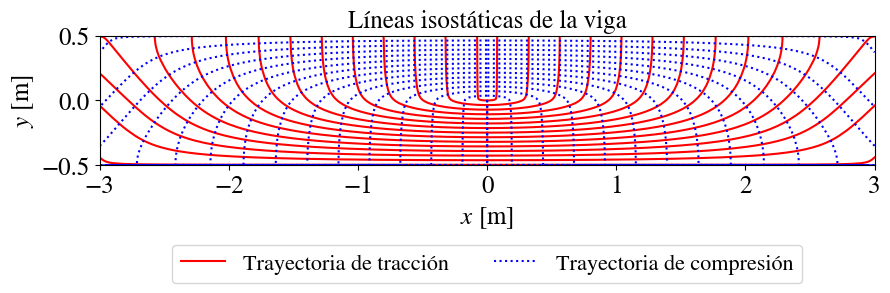

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Figure saved to: results_plots/lineas_isostaticas_viga.pdf
Figure saved to: results_plots/lineas_isostaticas_viga.eps
Figure saved to: results_plots/lineas_isostaticas_viga.png


In [21]:
fig, ax = plt.subplots(figsize=(10, 3))

h1 = ax.plot( x1, y1, 'r-', label='Trayectoria de tracción')[0]
ax.plot(-x1, y1, 'r-')
h2 = ax.plot( x2, y2, 'b:', label='Trayectoria de compresión')[0]
ax.plot(-x2, y2, 'b:')

ax.set_aspect('equal')
ax.axis([-L, L, -c, c])
ax.legend(handles=[h1, h2], loc='lower center', bbox_to_anchor=(0.5, -1.0), ncols=2)

# Se especifican los ejes y el título, y se colocan los ejes iguales.
ax.set_xlabel("$x$ [m]")
ax.set_ylabel("$y$ [m]", rotation = 90)
ax.set_title("Líneas isostáticas de la viga")

plt.show()
save_image(fig, "lineas_isostaticas_viga")

Fin :)